In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import random_split

In [2]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [3]:
dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

100%|██████████| 170M/170M [00:04<00:00, 42.6MB/s]


In [4]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
def train_model(model, optimizer, train_loader, val_loader, test_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    val_accs = []

    for epoch in range(epochs):
        # ===== TRAIN =====
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_losses.append(val_loss / len(val_loader))
        val_acc = 100 * correct / total
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # ===== TEST =====
    model.eval()
    correct = 0
    total = 0
    test_loss = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    test_loss = test_loss / len(test_loader)

    return train_losses, val_losses, val_accs, test_acc, test_loss

Experiment 1 — Adam

In [8]:
model1 = CNN().to(device)
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)

adam_results = train_model(model1, optimizer1, train_loader, val_loader, test_loader, epochs=10)

Epoch 1 | Train Loss: 1.5331 | Val Acc: 56.59%
Epoch 2 | Train Loss: 1.1864 | Val Acc: 63.34%
Epoch 3 | Train Loss: 1.0359 | Val Acc: 67.91%
Epoch 4 | Train Loss: 0.9452 | Val Acc: 70.40%
Epoch 5 | Train Loss: 0.8905 | Val Acc: 71.17%
Epoch 6 | Train Loss: 0.8527 | Val Acc: 73.60%
Epoch 7 | Train Loss: 0.8090 | Val Acc: 72.94%
Epoch 8 | Train Loss: 0.7824 | Val Acc: 75.55%
Epoch 9 | Train Loss: 0.7575 | Val Acc: 75.95%
Epoch 10 | Train Loss: 0.7464 | Val Acc: 74.48%


Experiment 2 — SGD

In [9]:
model2 = CNN().to(device)
optimizer2 = optim.SGD(model2.parameters(), lr=0.01)

sgd_results = train_model(model2, optimizer2, train_loader, val_loader, test_loader, epochs=10)

Epoch 1 | Train Loss: 1.6489 | Val Acc: 49.52%
Epoch 2 | Train Loss: 1.3363 | Val Acc: 55.60%
Epoch 3 | Train Loss: 1.1925 | Val Acc: 59.88%
Epoch 4 | Train Loss: 1.0991 | Val Acc: 63.17%
Epoch 5 | Train Loss: 1.0343 | Val Acc: 66.95%
Epoch 6 | Train Loss: 0.9823 | Val Acc: 67.83%
Epoch 7 | Train Loss: 0.9338 | Val Acc: 68.54%
Epoch 8 | Train Loss: 0.9005 | Val Acc: 71.17%
Epoch 9 | Train Loss: 0.8625 | Val Acc: 71.82%
Epoch 10 | Train Loss: 0.8316 | Val Acc: 72.49%


In [10]:
print("\n===== FINAL RESULTS =====\n")

print("| Model | Optimizer | Test Accuracy | Test Loss |")
print("|------|----------|--------------|----------|")

print(f"| A | Adam | {adam_results[3]:.2f}% | {adam_results[4]:.4f} |")
print(f"| B | SGD | {sgd_results[3]:.2f}% | {sgd_results[4]:.4f} |")


===== FINAL RESULTS =====

| Model | Optimizer | Test Accuracy | Test Loss |
|------|----------|--------------|----------|
| A | Adam | 75.42% | 0.7110 |
| B | SGD | 75.04% | 0.7116 |


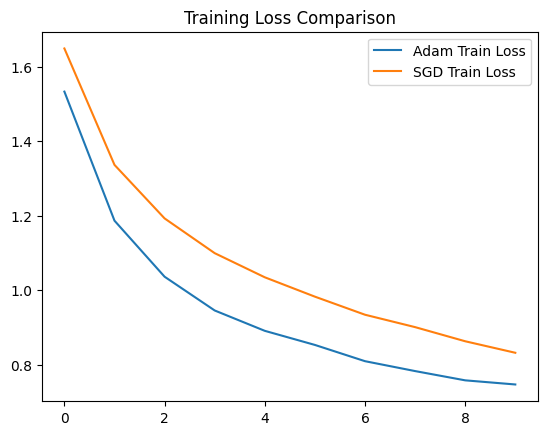

In [11]:
plt.plot(adam_results[0], label="Adam Train Loss")
plt.plot(sgd_results[0], label="SGD Train Loss")

plt.title("Training Loss Comparison")
plt.legend()
plt.show()

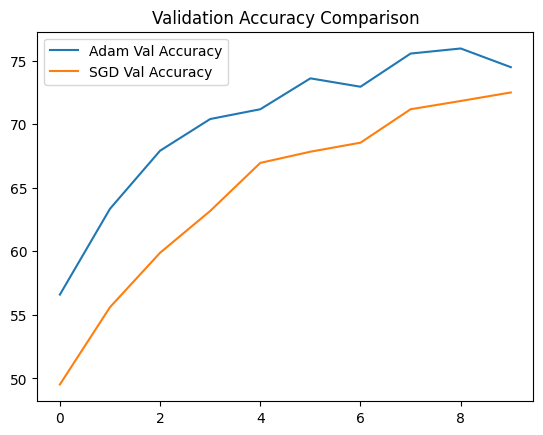

In [12]:
plt.plot(adam_results[2], label="Adam Val Accuracy")
plt.plot(sgd_results[2], label="SGD Val Accuracy")

plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()